In [1]:
import sqlite3
import pandas as pd

db_path = "mydb.db"

conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM wb_products", conn)
conn.close()

df.head()

,id,nm_id,vendor_code,wb_product_name,brand_id,category_id,supplier_id,adult,vat,height_mm,length_mm,width_mm,weight_g,created_at,updated_at
0,1,111111,ABC-123,Тестовый кроссовок 1,1,1,1,0,20.0,None,None,None,None,None,2026-04-18 14:17:10
1,3,222222,ABC-124,Тестовый кроссовок 2,1,1,1,0,20.0,None,None,None,None,None,2026-04-18 14:34:47
2,4,333333,ABC-125,Тестовый кроссовок 3,1,1,1,0,20.0,None,None,None,None,None,2026-04-18 14:34:47
3,5,104857621,SHOES-AX1,Кроссовки беговые мужские AirRun X1,12,3401,501,0,20.0,None,None,None,None,None,2026-04-18 14:35:53
4,6,104857622,TSHIRT-BS2,Футболка базовая оверсайз хлопок,13,3402,501,0,20.0,None,None,None,None,None,2026-04-18 14:35:53


In [2]:
df = df.copy()

df["name_len"] = df["wb_product_name"].fillna("").str.len()
df["vendor_len"] = df["vendor_code"].fillna("").str.len()
df["has_shoes"] = df["wb_product_name"].fillna("").str.lower().str.contains("кроссовк|обув|ботин").astype(int)
df["has_clothes"] = df["wb_product_name"].fillna("").str.lower().str.contains("футболк|куртк|джинс|рубашк|плать").astype(int)

df.head()

,id,nm_id,vendor_code,wb_product_name,brand_id,category_id,supplier_id,adult,vat,height_mm,length_mm,width_mm,weight_g,created_at,updated_at,name_len,vendor_len,has_shoes,has_clothes
0,1,111111,ABC-123,Тестовый кроссовок 1,1,1,1,0,20.0,None,None,None,None,None,2026-04-18 14:17:10,20,7,0,0
1,3,222222,ABC-124,Тестовый кроссовок 2,1,1,1,0,20.0,None,None,None,None,None,2026-04-18 14:34:47,20,7,0,0
2,4,333333,ABC-125,Тестовый кроссовок 3,1,1,1,0,20.0,None,None,None,None,None,2026-04-18 14:34:47,20,7,0,0
3,5,104857621,SHOES-AX1,Кроссовки беговые мужские AirRun X1,12,3401,501,0,20.0,None,None,None,None,None,2026-04-18 14:35:53,35,9,1,0
4,6,104857622,TSHIRT-BS2,Футболка базовая оверсайз хлопок,13,3402,501,0,20.0,None,None,None,None,None,2026-04-18 14:35:53,32,10,0,1


In [3]:
import numpy as np

df["target"] = np.random.randint(0, 100, size=len(df))

In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = ["brand_id", "category_id", "supplier_id", "vat", "name_len", "vendor_len", "has_shoes", "has_clothes"]
X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 17.5
R2: -0.7845157384872437


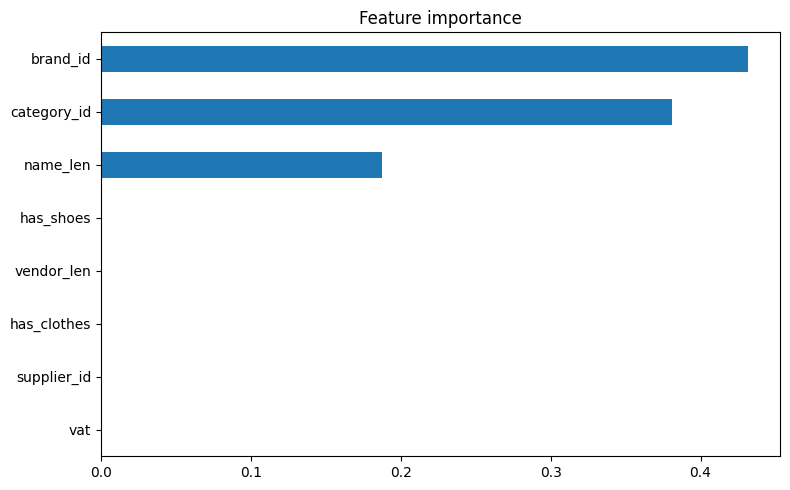

In [5]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Feature importance")
plt.tight_layout()
plt.show()